100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [01:27<00:00,  4.38s/it]


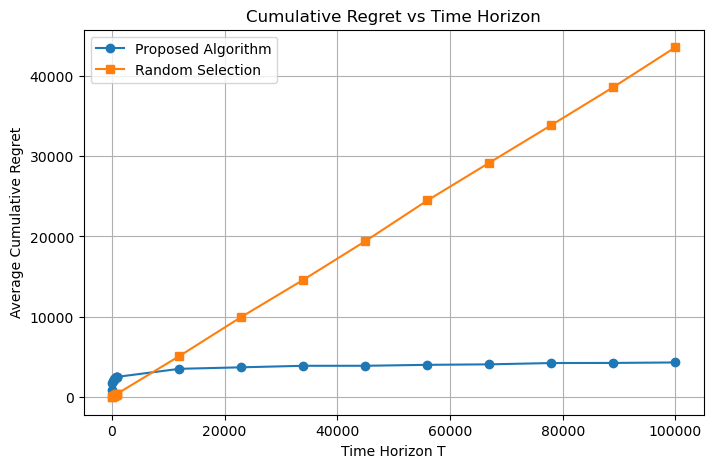

In [1]:
import numpy as np
import math
import itertools
import matplotlib.pyplot as plt
from tqdm import tqdm
import pdb
# -------- Parameters --------
N = 3         # number of channels
L = 3         # maximum load per channel (load levels: 1, 2, 3)
K = 9         # total number of users (assumes K = N*L)
# True means for each channel and load level: mu_true[m,l] with l=0,...,L-1 corresponds to load 1...L.
mu_true = np.array([[0.9, 0.8, 0.6],   # Channel 1: decreasing as load increases
                    [0.8, 0.7, 0.5],    # Channel 2
                    [0.7, 0.6, 0.4]])   # Channel 3

# Noise parameters: use a small variance
var_true = 0.01      # variance used for reward generation
std_true = np.sqrt(var_true)
clip_low, clip_high = 0.0, 1.0

# Algorithm parameters
Delta = 0.05          # target estimation accuracy
# Bernstein-based T0:
def compute_T0(T, sigma2=var_true, Delta=Delta):
    #pdb.set_trace()
    return int((2 * sigma2 + (2/3)*Delta) / (Delta**2) * np.log10(T))

# For simulation averaging
num_runs = 1

# -------- Helper Functions --------
def clip_rewards(rewards):
    return np.clip(rewards, clip_low, clip_high)

def sample_rewards(mu, n_samples):
    samples = np.random.normal(mu, std_true, n_samples)
    return clip_rewards(samples)

def estimate_means(T0, mu_true):
    """
    For each configuration (channel m and load level l),
    draw T0 samples from Normal(mu_true[m,l], std_true) and compute sample mean.
    Returns an estimated mean matrix (N x L).
    """
    est = np.zeros((N, L))
    for m in range(N):
        for l in range(L):
            samples = sample_rewards(mu_true[m, l], T0)
            est[m, l] = np.mean(samples)
    return est

def feasible_allocations(N, L, K):
    allocs = []
    for alloc in itertools.product(range(L+1), repeat=N):
        if sum(alloc) == K:
            allocs.append(alloc)
    return allocs

def compute_total_reward(alloc, mean_matrix):
    total = 0.0
    for m, k in enumerate(alloc):
        if k > 0:
            # load level is index k-1 (since load levels are 1,...,L)
            total += k * mean_matrix[m, k-1]
    return total

def get_optimal_allocation(mean_matrix):
    allocs = feasible_allocations(N, L, K)
    best_alloc = None
    best_reward = -np.inf
    for alloc in allocs:
        r = compute_total_reward(alloc, mean_matrix)
        if r > best_reward:
            best_reward = r
            best_alloc = alloc
    return best_alloc, best_reward

# -------- Proposed Algorithm Simulation --------
def simulate_proposed(T):
    """
    Simulate one run of the proposed one-phase estimation (with T0 per configuration)
    and allocation algorithm over a time horizon T.
    Time is divided into estimation phase (T_e) and allocation phase (T_a = T - T_e).
    """
    T0 = compute_T0(T)
    T_e = N * L * T0   # total estimation phase time slots
    T_a = max(T - T_e, 0)
    
    # Estimation Phase: estimate means for each (m, load)
    est_means = estimate_means(T0, mu_true)
    est_alloc, _ = get_optimal_allocation(est_means)
    
    # Oracle (True) optimal allocation
    true_alloc, true_alloc_reward = get_optimal_allocation(mu_true)
    
    # Allocation Phase: simulate T_a time slots using the estimated allocation
    reward_alloc = 0.0
    for t in range(T_a):
        slot_reward = 0.0
        for m, k in enumerate(est_alloc):
            if k > 0:
                samples = sample_rewards(mu_true[m, k-1], k)
                slot_reward += np.sum(samples)
        reward_alloc += slot_reward
    
    # Worst-case estimation phase regret: assume optimal per-slot reward is true_alloc_reward
    regret_estimation = true_alloc_reward * T_e
    # Allocation phase regret: difference between optimal reward and actual reward in allocation
    optimal_alloc_reward = true_alloc_reward * T_a
    regret_allocation = optimal_alloc_reward - reward_alloc
    
    total_regret = regret_estimation + regret_allocation
    #pdb.set_trace()
    return total_regret

# -------- Random Selection Baseline Simulation --------
def simulate_random(T):
    """
    Simulate one run of a random selection strategy over time horizon T.
    At each time slot, each user picks a channel uniformly at random.
    Compute the total reward and regret relative to the oracle.
    """
    # Oracle total reward if using optimal allocation in every slot (true optimal allocation)
    _, true_alloc_reward = get_optimal_allocation(mu_true)
    optimal_total_reward = true_alloc_reward * T
    
    total_reward = 0.0
    for t in range(T):
        # Each user independently selects a channel uniformly at random
        # Create an array of channel choices for K users.
        channel_choices = np.random.choice(N, K)
        # Compute load for each channel
        loads = [np.sum(channel_choices == m) for m in range(N)]
        slot_reward = 0.0
        # For each channel, if load > 0, determine reward using the corresponding load level (index = load-1)
        for m, k in enumerate(loads):
            if k > 0:
                # Ensure that if k > L, we clip it to L (since our model assumes at most L users can yield nonzero reward)
                effective_load = min(k, L)
                samples = sample_rewards(mu_true[m, effective_load-1], effective_load)
                slot_reward += np.sum(samples)
        total_reward += slot_reward
    # Regret: difference between optimal total reward and random strategy total reward.
    regret = optimal_total_reward - total_reward
    return regret

# -------- Running Simulations --------
T_values = np.linspace(1000, 100000, 10, dtype=int)
T_values1 = np.linspace(10, 1000, 10, dtype=int)
T_values = list(np.concatenate([T_values1, T_values]))
#T_values = [10000]
proposed_regrets = []
random_regrets = []

for T in tqdm(T_values):
    reg_prop = []
    reg_rand = []
    for _ in range(num_runs):
        reg_prop.append(simulate_proposed(T))
        reg_rand.append(simulate_random(T))
    #pdb.set_trace()
    proposed_regrets.append(np.mean(reg_prop))
    random_regrets.append(np.mean(reg_rand))
    
# Plotting the results
plt.figure(figsize=(8,5))
plt.plot(T_values, proposed_regrets, marker='o', label='Proposed Algorithm')
plt.plot(T_values, random_regrets, marker='s', label='Random Selection')
plt.xlabel('Time Horizon T')
plt.ylabel('Average Cumulative Regret')
plt.title('Cumulative Regret vs Time Horizon')
plt.legend()
plt.grid(True)
plt.show()


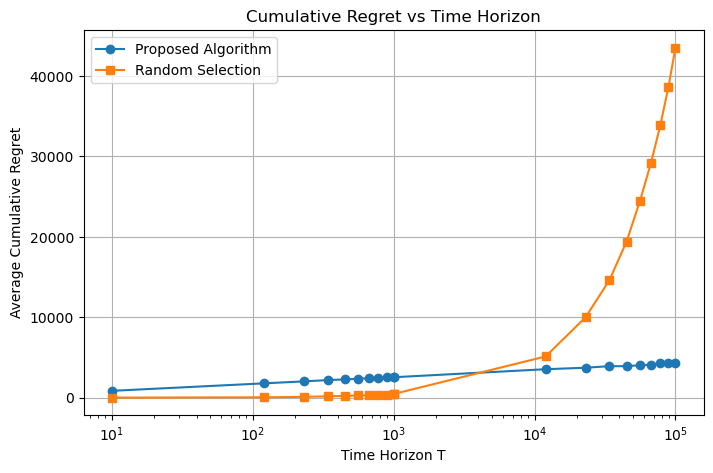

In [2]:
plt.figure(figsize=(8,5))
plt.semilogx(T_values, proposed_regrets, marker='o', label='Proposed Algorithm')
plt.plot(T_values, random_regrets, marker='s', label='Random Selection')
plt.xlabel('Time Horizon T')
plt.ylabel('Average Cumulative Regret')
plt.title('Cumulative Regret vs Time Horizon')
plt.legend()
plt.grid(True)
plt.show()